# Detached EEG Pipeline (Joint Standalone)

**RQ2 — Joint Training** experiment on Google Colab.

- **Phase 1**: GPU-accelerated feature matrix generation (sequential, one model at a time on GPU)
- **Phase 2**: LOSO folds evaluated in **parallel across 8 CPU cores**
- **Two-level checkpointing**: feature cache + per-run fold results

### Recovery Instructions

After a Colab disconnection:
1. **Runtime → Run all** from the top.
2. The pipeline will automatically:
   - Load the **feature matrix cache** from `results/cache_joint/`
   - Resume the **LOSO loop** from where it left off


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/Colab' 
os.chdir(PROJECT_ROOT)
print('Working directory:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Colab


In [2]:
import os, sys

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

# Pinning numpy<2.0.0 is critical to avoid the "numpy.char" error
!pip install mne "numpy<2.0.0" scikit-learn pyts torch matplotlib "sktime==0.30.0" joblib psutil --quiet
!pip install git+https://github.com/gon-uri/detach_rocket --quiet
print('✓ Dependencies installed.')


  Preparing metadata (setup.py) ... done
✓ Dependencies installed.


In [3]:
from IPython.display import display, Javascript
display(Javascript('''
function ClickConnect(){
    console.log("[keep-alive] Simulating activity.");
    var btn = document.querySelector("colab-toolbar-button#connect");
    if (btn) btn.click();
}
setInterval(ClickConnect, 60000);
'''))
print('✓ Keep-alive activated.')


<IPython.core.display.Javascript object>

✓ Keep-alive activated.


In [4]:
import os
# These MUST be set before importing numpy or sklearn to prevent RAM spikes
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import gc, hashlib, json, datetime, sys
import numpy as np
import mne
import psutil
from typing import Dict, Any, List
from sklearn.metrics import accuracy_score, classification_report
from joblib import Parallel, delayed

from src.utl.config import load_config

try:
    from detach_rocket.detach_classes import PytorchMiniRocketMultivariate, DetachMatrix
except ImportError:
    from detach_rocket.detach_rocket import PytorchMiniRocketMultivariate, DetachMatrix

mne.set_log_level('WARNING')
print('✓ Imports and thread limits applied.')


✓ Imports and thread limits applied.


In [5]:
def _worker_process_fold(split, cache_dir, num_models, y_all, s_indices, trade_off):
    """
    Processes one LOSO fold using memory-mapped feature matrices to share RAM.
    """
    import gc, os
    import numpy as np
    from sklearn.metrics import accuracy_score
    try:
        from detach_rocket.detach_classes import DetachMatrix
    except ImportError:
        from detach_rocket.detach_rocket import DetachMatrix

    test_sub_id  = split['test_subjects'][0]
    test_sub_idx = split['val_idx']
    train_mask   = s_indices != test_sub_idx
    test_mask    = s_indices == test_sub_idx

    y_train = y_all[train_mask]
    y_test  = y_all[test_mask]

    model_outputs = []
    model_weights = []

    for m in range(num_models):
        # Load via mmap to avoid duplicating the full 5GB+ array in RAM
        matrix_path = os.path.join(cache_dir, f'feature_matrix_{m}.npy')
        F = np.load(matrix_path, mmap_mode='r')

        # Create small local float32 copies of just the rows we need
        F_train = np.asarray(F[train_mask], dtype=np.float32)
        F_test  = np.asarray(F[test_mask],  dtype=np.float32)
        del F # Close the mmap reference

        model = DetachMatrix(trade_off=trade_off)
        model.fit(F_train, y_train)
        model_outputs.append(model.predict(F_test))
        model_weights.append(model._acc_train)

        del F_train, F_test, model
        gc.collect()

    model_outputs  = np.array(model_outputs).T
    weights        = np.array(model_weights)
    y_pred_probas  = (model_outputs * weights).sum(axis=1) / weights.sum()
    y_pred_trials  = (y_pred_probas >= 0.5).astype(int)
    y_pred_subject = 1 if np.mean(y_pred_trials) >= 0.5 else 0

    return {
        'subject':        test_sub_id,
        'y_true':         int(y_test[0]),
        'y_pred':         int(y_pred_subject),
        'trial_accuracy': float(accuracy_score(y_test, y_pred_trials))
    }

print('✓ Worker function defined.')


✓ Worker function defined.


In [6]:
import gc, hashlib, json, datetime, os, sys
import numpy as np
import psutil

class TaskEEGPipeline:
    CACHE_DIR    = 'results/cache_joint'
    RESULTS_PATH = 'results/loso_results_joint.json'

    @property
    def N_JOBS(self):
        # 4 is the safest maximum for Colab to prevent SIGKILL
        return 4

    def __init__(self, config_path='config.yml'):
        self.config      = load_config(config_path)
        self.data_path   = self.config.get('data', {}).get('joint', './data/processed/joint_dataset/joint_trials.npz')
        self.split_seed  = self.config.get('experiment', {}).get('seed', 42)
        self.trade_off   = self.config.get('experiment', {}).get('trade_off', 0.1)

        self.all_subjects:         List[str] = []
        self.splits:               List[Dict] = []
        self.processed_folds_data: List[Dict] = []
        self.completed_subjects:   List[str] = []

        self._print_hw_status()

    def _print_hw_status(self):
        import torch, psutil
        sep      = '=' * 45
        cuda     = torch.cuda.is_available()
        gpu_name = torch.cuda.get_device_name(0) if cuda else 'N/A'
        ram      = psutil.virtual_memory()
        print(f'\n{sep}\nHARDWARE STATUS\n{sep}')
        print(f'GPU  : {"YES — " + gpu_name if cuda else "NO"}')
        print(f'RAM  : {ram.available/(1024**3):.1f}GB free / {ram.total/(1024**3):.1f}GB total')
        print(f'CPUs : {os.cpu_count()} total | {self.N_JOBS} assigned to LOSO')
        print(f'{sep}\n')

    def _cache_key(self):
        params  = self.config.get('model', {}).get('params', {})
        key_str = json.dumps({'num_models': params.get('num_models', 10), 'num_kernels': params.get('num_kernels', 10000), 'data_path': self.data_path}, sort_keys=True)
        return hashlib.md5(key_str.encode()).hexdigest()

    def _save_cache(self, feature_matrices):
        os.makedirs(self.CACHE_DIR, exist_ok=True)
        print(f'\nPhase 1: Saving {len(feature_matrices)} matrices as float32...')
        for m, F in enumerate(feature_matrices):
            np.save(os.path.join(self.CACHE_DIR, f'feature_matrix_{m}.npy'), F.astype(np.float32))
            print(f'  Saved matrix {m+1}/{len(feature_matrices)}')
        meta = {'cache_key': self._cache_key(), 'num_models': len(feature_matrices), 'created_at': datetime.datetime.utcnow().isoformat()}
        with open(os.path.join(self.CACHE_DIR, 'cache_meta.json'), 'w') as f:
            json.dump(meta, f, indent=4)

    def _load_cache(self):
        meta_path = os.path.join(self.CACHE_DIR, 'cache_meta.json')
        if not os.path.exists(meta_path): return None
        with open(meta_path) as f: meta = json.load(f)
        if meta.get('cache_key') != self._cache_key(): return None
        return [os.path.join(self.CACHE_DIR, f'feature_matrix_{m}.npy') for m in range(meta['num_models'])]

    def _save_checkpoint(self, y_pred, y_true, folds):
        os.makedirs('results', exist_ok=True)
        run = {'config': self.config, 'subject_level_accuracy': accuracy_score(y_true, y_pred), 'folds': folds}
        all_runs = []
        if os.path.exists(self.RESULTS_PATH) and os.path.getsize(self.RESULTS_PATH) > 0:
            with open(self.RESULTS_PATH) as f: all_runs = json.load(f)
        all_runs.append(run)
        with open(self.RESULTS_PATH, 'w') as f: json.dump(all_runs, f, indent=4)
        print(f'✓ Checkpoint saved ({len(folds)} folds).')

    def initialize(self):
        if not os.path.exists(self.data_path): return
        data = np.load(self.data_path)
        self.all_subjects = data['subject_list'].tolist()
        if os.path.exists(self.RESULTS_PATH) and os.path.getsize(self.RESULTS_PATH) > 0:
            with open(self.RESULTS_PATH) as f:
                all_runs = json.load(f)
                self.processed_folds_data = all_runs[-1].get('folds', [])
                self.completed_subjects = [f['subject'] for f in self.processed_folds_data]
        remaining = [s for s in self.all_subjects if s not in self.completed_subjects]
        self.splits = [{'train_subjects': [s for s in self.all_subjects if s != sub], 'test_subjects': [sub], 'val_idx': self.all_subjects.index(sub)} for sub in remaining]

    def run(self):
        self.initialize()
        if not self.splits and not self.processed_folds_data: return
        
        raw = np.load(self.data_path)
        y_all, s_indices = raw['y'], raw['subject_indices']
        cache_paths = self._load_cache()

        if cache_paths is None:
            import torch
            X_all = raw['X']
            params = self.config.get('model', {}).get('params', {})
            num_models, num_kernels = params.get('num_models', 10), params.get('num_kernels', 10000)
            feature_matrices = []
            for m in range(num_models):
                print(f'Generating Matrix {m+1}/{num_models} on GPU...')
                transformer = PytorchMiniRocketMultivariate(num_features=num_kernels, device='cuda')
                transformer.fit(X_all)
                feature_matrices.append(transformer.transform(X_all).numpy())
                del transformer; gc.collect()
            self._save_cache(feature_matrices)
            del X_all, feature_matrices; gc.collect()
            cache_paths = [os.path.join(self.CACHE_DIR, f'feature_matrix_{m}.npy') for m in range(num_models)]
        
        # Free memory before starting parallel phase
        gc.collect()

        if self.splits:
            print(f'\nPhase 2: Running {len(self.splits)} folds in parallel (verbose=10)...')
            new_results = Parallel(n_jobs=self.N_JOBS, backend='loky', verbose=10)(
                delayed(_worker_process_fold)(s, self.CACHE_DIR, len(cache_paths), y_all, s_indices, self.trade_off) 
                for s in self.splits
            )
            self.processed_folds_data.extend(new_results)

        y_pred = [f['y_pred'] for f in self.processed_folds_data]
        y_true = [f['y_true'] for f in self.processed_folds_data]
        if y_pred:
            print(f'\nFinal Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%')
            self._save_checkpoint(y_pred, y_true, self.processed_folds_data)

print('✓ Pipeline class defined.')


✓ Pipeline class defined.


In [7]:
if __name__ == '__main__':
    pipeline = TaskEEGPipeline()
    pipeline.run()



HARDWARE STATUS
GPU  : YES — NVIDIA L4
RAM  : 51.0GB free / 53.0GB total
CPUs : 12 total | 4 assigned to LOSO

Generating Matrix 1/10 on GPU...
Generating Matrix 2/10 on GPU...
Generating Matrix 3/10 on GPU...
Generating Matrix 4/10 on GPU...
Generating Matrix 5/10 on GPU...
Generating Matrix 6/10 on GPU...
Generating Matrix 7/10 on GPU...
Generating Matrix 8/10 on GPU...
Generating Matrix 9/10 on GPU...
Generating Matrix 10/10 on GPU...

Phase 1: Saving 10 matrices as float32...
  Saved matrix 1/10
  Saved matrix 2/10
  Saved matrix 3/10
  Saved matrix 4/10
  Saved matrix 5/10
  Saved matrix 6/10
  Saved matrix 7/10
  Saved matrix 8/10
  Saved matrix 9/10
  Saved matrix 10/10


/tmp/ipykernel_4259/517257302.py:50: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  meta = {'cache_key': self._cache_key(), 'num_models': len(feature_matrices), 'created_at': datetime.datetime.utcnow().isoformat()}



Phase 2: Running 65 folds in parallel (verbose=10)...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  3.2min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  4.7min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed: 14.0min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed: 21.8min



Final Accuracy: 90.77%
✓ Checkpoint saved (65 folds).


[Parallel(n_jobs=4)]: Done  65 out of  65 | elapsed: 26.4min finished


Subject-Level Accuracy : 90.77%
Paper Target           : 86.15%



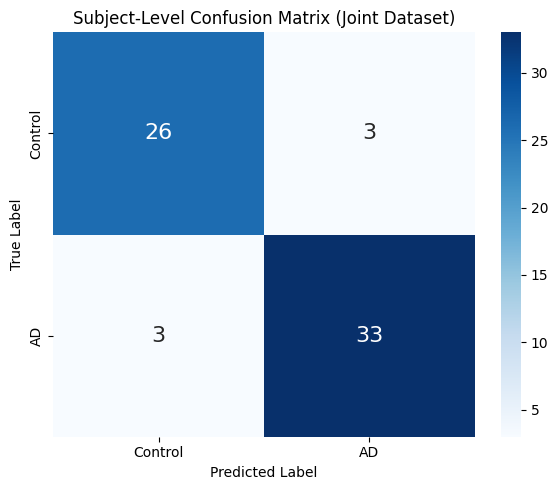

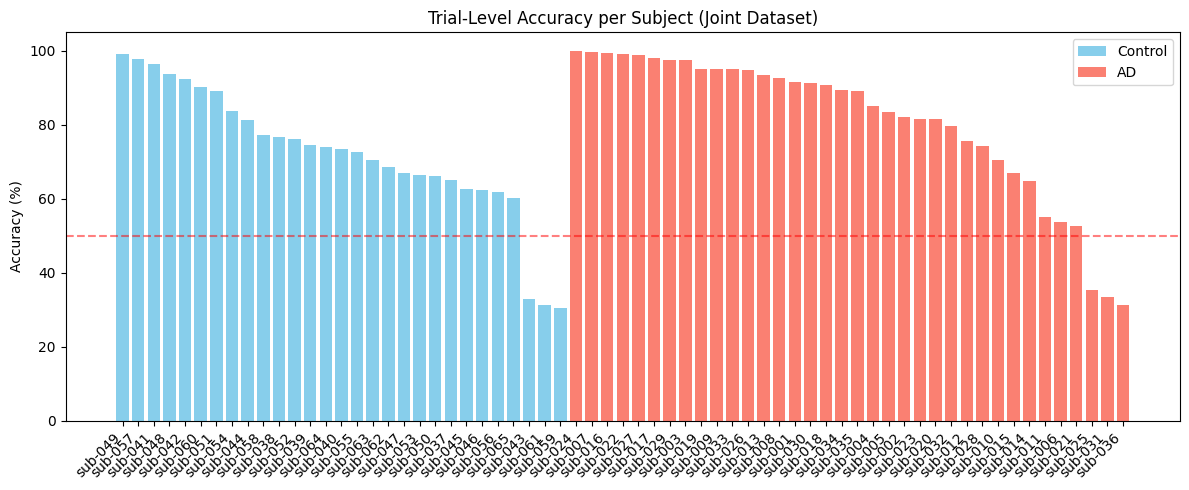

In [8]:
import json, os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

def load_results(path='results/loso_results_joint.json'):
    if not os.path.exists(path):
        print(f'Not found: {path}')
        return None
    with open(path) as f:
        data = json.load(f)
    return data[-1] if isinstance(data, list) else data

def plot_confusion_matrix(results):
    y_true = [fo['y_true'] for fo in results['folds']]
    y_pred = [fo['y_pred'] for fo in results['folds']]
    cm    = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm, index=['Control', 'AD'], columns=['Control', 'AD'])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues', ax=ax, annot_kws={'size': 16})
    ax.set_title('Subject-Level Confusion Matrix (Joint Dataset)')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    return fig

def plot_trial_accuracy(results):
    df = pd.DataFrame(results['folds'])
    df.sort_values(['y_true', 'trial_accuracy'], ascending=[True, False], inplace=True)
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['skyblue' if y == 0 else 'salmon' for y in df['y_true']]
    ax.bar(df['subject'], df['trial_accuracy'] * 100, color=colors)
    ax.axhline(50, color='red', linestyle='--', alpha=0.5, label='Random Chance')
    ax.set_title('Trial-Level Accuracy per Subject (Joint Dataset)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_xticks(range(len(df))); ax.set_xticklabels(df['subject'], rotation=45, ha='right')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='skyblue', label='Control'), Patch(facecolor='salmon', label='AD')])
    plt.tight_layout()
    return fig

results = load_results()
if results:
    os.makedirs('results/figures', exist_ok=True)
    print(f"Subject-Level Accuracy : {results['subject_level_accuracy']*100:.2f}%")
    print(f"Paper Target           : {results.get('paper_target_accuracy', 0.8615)*100:.2f}%\n")
    plot_confusion_matrix(results); plt.show()
    plot_trial_accuracy(results);   plt.show()
